# Week 4 Internship Project
## Supervised Learning Model Implementation — Titanic Survival Prediction

**Internship:** Virtual Data Science with Python Trainee  
**Platform:** YuvaIntern / NSDC  
**Task:** Week 4 — Supervised Learning Model Implementation

### Problem Statement
Build a supervised machine learning classification model to predict whether a Titanic passenger survived using demographic, socioeconomic, and travel-related information.

**Target:** `survived` — `0` = did not survive, `1` = survived.

### Objectives
1. Understand and prepare the dataset.
2. Perform data-quality checks and exploratory analysis.
3. Engineer meaningful predictive features.
4. Compare classification models.
5. Validate models with stratified cross-validation.
6. Evaluate accuracy, precision, recall, F1-score, ROC-AUC and the confusion matrix.
7. Tune the stronger model.
8. Interpret results and discuss strengths, limitations and improvements.

> Preprocessing is kept inside Scikit-learn pipelines so that transformations are learned from training data during validation, reducing data leakage.

In [5]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, ConfusionMatrixDisplay,
    RocCurveDisplay
)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Dataset Acquisition

The Titanic dataset is a publicly available benchmark dataset for binary classification. It contains passenger information including passenger class, sex, age, family-related variables, fare, embarkation details and survival status.

The dataset is loaded through Seaborn's public dataset interface for reproducibility.

In [6]:
df = pd.read_csv("Titanic-Dataset.csv")

# Make Kaggle Titanic column names compatible with the remaining notebook
df = df.rename(columns={
    "Survived": "survived",
    "Pclass": "pclass",
    "Sex": "sex",
    "Age": "age",
    "SibSp": "sibsp",
    "Parch": "parch",
    "Fare": "fare",
    "Embarked": "embarked",
    "Cabin": "deck"
})

# Add columns expected by later cells
df["class"] = df["pclass"].map({
    1: "First",
    2: "Second",
    3: "Third"
})
df["alive"] = df["survived"].map({0: "no", 1: "yes"})
df["embark_town"] = df["embarked"]
df["who"] = np.where(
    df["age"] < 16,
    "child",
    np.where(df["sex"] == "female", "woman", "man")
)
df["adult_male"] = ((df["age"] >= 16) & (df["sex"] == "male")).fillna(False)
df["alone"] = ((df["sibsp"] + df["parch"]) == 0)

print("Dataset shape:", df.shape)
display(df.head())

print("\nDataset information:")
df.info()

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
display(df["survived"].value_counts())
display(df["survived"].value_counts(normalize=True).rename("proportion"))

print("Dataset shape:", df.shape)
display(df.head())

print("\nDataset information:")
df.info()

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
display(df["survived"].value_counts())
display(df["survived"].value_counts(normalize=True).rename("proportion"))

Dataset shape: (891, 18)


,PassengerId,survived,pclass,Name,sex,age,sibsp,parch,Ticket,fare,deck,embarked,class,alive,embark_town,who,adult_male,alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Third,no,S,man,True,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,First,yes,C,woman,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Third,yes,S,woman,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,First,yes,S,woman,False,False
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Third,no,S,man,True,True



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   sex          891 non-null    str    
 5   age          714 non-null    float64
 6   sibsp        891 non-null    int64  
 7   parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   fare         891 non-null    float64
 10  deck         204 non-null    str    
 11  embarked     889 non-null    str    
 12  class        891 non-null    str    
 13  alive        891 non-null    str    
 14  embark_town  889 non-null    str    
 15  who          891 non-null    str    
 16  adult_male   891 non-null    bool   
 17  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(5), str(9

deck           687
age            177
embarked         2
embark_town      2
survived         0
PassengerId      0
sibsp            0
pclass           0
Name             0
sex              0
fare             0
Ticket           0
parch            0
class            0
alive            0
who              0
adult_male       0
alone            0
dtype: int64


Duplicate rows: 0

Target distribution:


...


Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   sex          891 non-null    str    
 5   age          714 non-null    float64
 6   sibsp        891 non-null    int64  
 7   parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   fare         891 non-null    float64
 10  deck         204 non-null    str    
 11  embarked     889 non-null    str    
 12  class        891 non-null    str    
 13  alive        891 non-null    str    
 14  embark_town  889 non-null    str    
 15  who          891 non-null    str    
 16  adult_male   891 non-null    bool   
 17  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(5), str(9

deck           687
age            177
embarked         2
embark_town      2
survived         0
PassengerId      0
sibsp            0
pclass           0
Name             0
sex              0
fare             0
Ticket           0
parch            0
class            0
alive            0
who              0
adult_male       0
alone            0
dtype: int64


Duplicate rows: 0

Target distribution:


survived
0    549
1    342
Name: count, dtype: int64

survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

## 2. Exploratory Data Analysis

Before modeling, the target distribution and important variables are examined. This helps identify class balance and understand relationships that may be useful for feature engineering and model interpretation.

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


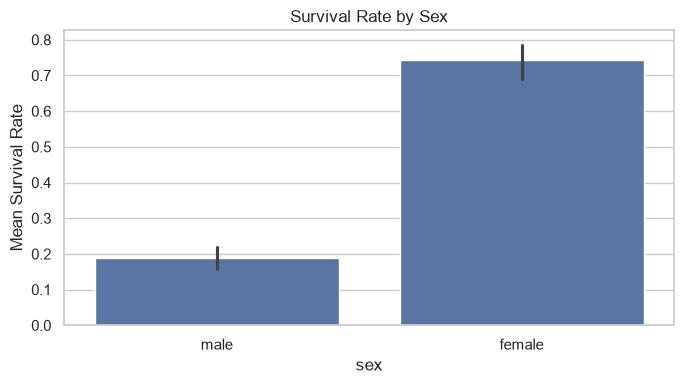

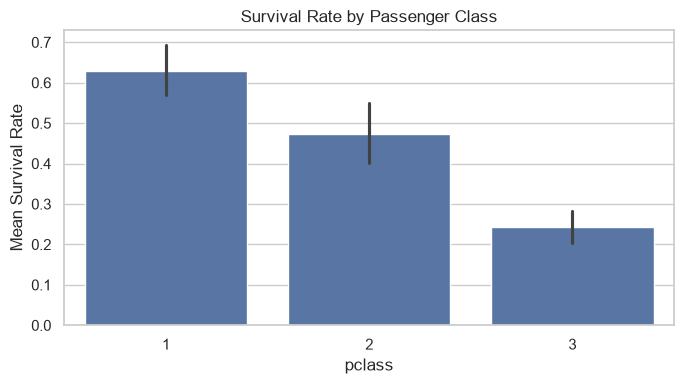

In [7]:
display(df.describe(include="all").T)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=df, x="sex", y="survived", ax=ax)
ax.set_title("Survival Rate by Sex")
ax.set_ylabel("Mean Survival Rate")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=df, x="pclass", y="survived", ax=ax)
ax.set_title("Survival Rate by Passenger Class")
ax.set_ylabel("Mean Survival Rate")
plt.tight_layout()
plt.show()

## 3. Feature Engineering and Selection

The following engineered features are used:

- **FamilySize = sibsp + parch + 1:** represents the passenger's immediate recorded family group size.
- **IsAlone:** indicates whether the passenger travelled without recorded family members.
- **FarePerPerson = fare / FamilySize:** gives an approximate individual fare burden within the family group.

### Feature-selection rationale

- `pclass` captures passenger class and socioeconomic/travel differences.
- `sex` and `age` provide demographic information.
- `sibsp` and `parch` provide original family information.
- `fare` provides ticket-price information.
- `embarked` captures embarkation location.
- The engineered family features provide additional travel-structure information.
- `alive` is explicitly excluded because it directly encodes the outcome and would cause **target leakage**.
- `deck` is excluded from the primary model because it has substantial missingness.
- Redundant convenience columns such as `who`, `adult_male`, `alone`, and `embark_town` are excluded so the feature set remains focused.

In [8]:
data = df.copy()

data["family_size"] = data["sibsp"] + data["parch"] + 1
data["is_alone"] = (data["family_size"] == 1).astype(int)
data["fare_per_person"] = data["fare"] / data["family_size"]

drop_cols = [
    "survived", "alive", "deck", "embark_town",
    "who", "adult_male", "alone"
]

X = data.drop(columns=drop_cols)
y = data["survived"].astype(int)

print("Feature matrix shape:", X.shape)
print("Features:")
print(X.columns.tolist())

print("\nMissing values in modeling features:")
display(X.isna().sum().sort_values(ascending=False))

Feature matrix shape: (891, 14)
Features:
['PassengerId', 'pclass', 'Name', 'sex', 'age', 'sibsp', 'parch', 'Ticket', 'fare', 'embarked', 'class', 'family_size', 'is_alone', 'fare_per_person']

Missing values in modeling features:


age                177
embarked             2
pclass               0
Name                 0
sex                  0
PassengerId          0
sibsp                0
parch                0
Ticket               0
fare                 0
class                0
family_size          0
is_alone             0
fare_per_person      0
dtype: int64

In [9]:
display(
    data[[
        "sibsp", "parch", "family_size",
        "is_alone", "fare", "fare_per_person"
    ]].head(10)
)

,sibsp,parch,family_size,is_alone,fare,fare_per_person
0,1,0,2,0,7.2500,3.62500
1,1,0,2,0,71.2833,35.64165
2,0,0,1,1,7.9250,7.92500
3,1,0,2,0,53.1000,26.55000
4,0,0,1,1,8.0500,8.05000
5,0,0,1,1,8.4583,8.45830
6,0,0,1,1,51.8625,51.86250
7,3,1,5,0,21.0750,4.21500
8,0,2,3,0,11.1333,3.71110
9,1,0,2,0,30.0708,15.03540


## 4. Train-Test Split

A **stratified 80/20 split** is used. Stratification preserves approximately the same survivor/non-survivor proportion in both sets.

The test set remains untouched until final evaluation. Imputation, scaling and categorical encoding are performed inside the modeling pipeline.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

print("\nTraining target proportions:")
display(y_train.value_counts(normalize=True).rename("proportion"))

print("\nTesting target proportions:")
display(y_test.value_counts(normalize=True).rename("proportion"))

Training samples: 712
Testing samples : 179

Training target proportions:


survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64


Testing target proportions:


survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64

## 5. Preprocessing Pipeline

### Numerical variables
- Missing values → median imputation
- Standardization → `StandardScaler`

### Categorical variables
- Missing values → most-frequent imputation
- Categories → one-hot encoding

Using `ColumnTransformer` and `Pipeline` ensures preprocessing is fitted only on the appropriate training portion during cross-validation.

In [11]:
numeric_features = [
    "age", "sibsp", "parch", "fare",
    "family_size", "is_alone", "fare_per_person"
]

categorical_features = [
    "pclass", "sex", "embarked", "class"
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline configured.")

Preprocessing pipeline configured.


## 6. Model Selection

Two complementary classifiers are compared.

### Logistic Regression
Used as an interpretable baseline for binary classification. It estimates the probability of survival from a weighted combination of input features.

### Random Forest
An ensemble of decision trees that can model nonlinear relationships and feature interactions. This is useful when survival patterns are more complex than a linear decision boundary.

Both models use the same preprocessing and validation framework for a fair comparison.

In [12]:
logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ))
])

models = {
    "Logistic Regression": logistic_pipeline,
    "Random Forest": rf_pipeline
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = []

for name, model in models.items():
    scores = cross_validate(
        model, X_train, y_train,
        cv=cv, scoring=scoring, n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "CV ROC-AUC": scores["test_roc_auc"].mean()
    })

cv_results_df = (
    pd.DataFrame(cv_results)
    .sort_values("CV ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

display(cv_results_df.round(4))

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC
0,Random Forest,0.7950,0.7204,0.7656,0.7417,0.8679
1,Logistic Regression,0.7992,0.7594,0.6998,0.7274,0.8557


## 7. Cross-Validation Analysis

Five-fold stratified cross-validation gives a more robust estimate of generalization than a single validation split.

The comparison considers:
- **Accuracy** — overall classification correctness.
- **Precision** — proportion of predicted survivors that actually survived.
- **Recall** — proportion of actual survivors correctly identified.
- **F1-score** — harmonic mean of precision and recall.
- **ROC-AUC** — ability to distinguish the two classes across probability thresholds.

The model with stronger validation performance is selected using cross-validation ROC-AUC.

In [13]:
# Fit both models on the training set
for model in models.values():
    model.fit(X_train, y_train)

test_results = []

for name, model in models.items():
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    test_results.append({
        "Model": name,
        "Test Accuracy": accuracy_score(y_test, pred),
        "Test Precision": precision_score(y_test, pred),
        "Test Recall": recall_score(y_test, pred),
        "Test F1": f1_score(y_test, pred),
        "Test ROC-AUC": roc_auc_score(y_test, prob)
    })

test_results_df = (
    pd.DataFrame(test_results)
    .sort_values("Test ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

display(test_results_df.round(4))

best_model_name = cv_results_df.loc[0, "Model"]
best_model = models[best_model_name]

print("Selected model based on CV ROC-AUC:", best_model_name)

,Model,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,Logistic Regression,0.8045,0.7833,0.6812,0.7287,0.8509
1,Random Forest,0.8045,0.7429,0.7536,0.7482,0.8175


Selected model based on CV ROC-AUC: Random Forest


## 8. Held-Out Test Evaluation

The selected model is evaluated on the test set that was not used during training or cross-validation.

The classification report and ROC-AUC provide complementary information about predictive performance.

In [14]:
best_pred = best_model.predict(X_test)
best_prob = best_model.predict_proba(X_test)[:, 1]

print("Selected model:", best_model_name)
print("\nClassification Report:")
print(classification_report(
    y_test,
    best_pred,
    target_names=["Did not survive", "Survived"]
))

print("ROC-AUC:", round(roc_auc_score(y_test, best_prob), 4))

Selected model: Random Forest

Classification Report:
                 precision    recall  f1-score   support

Did not survive       0.84      0.84      0.84       110
       Survived       0.74      0.75      0.75        69

       accuracy                           0.80       179
      macro avg       0.79      0.79      0.79       179
   weighted avg       0.81      0.80      0.80       179

ROC-AUC: 0.8175


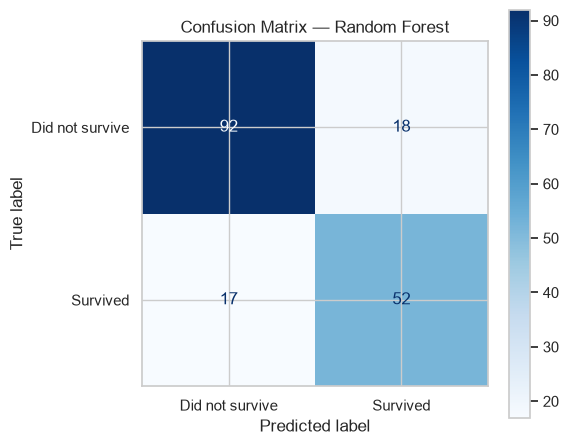

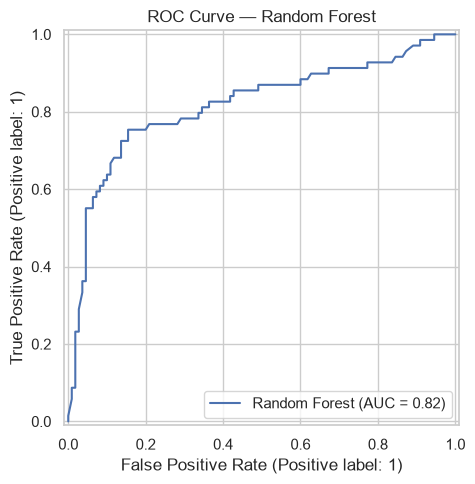

In [15]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_pred,
    display_labels=["Did not survive", "Survived"],
    cmap="Blues",
    ax=ax
)
ax.set_title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(
    y_test,
    best_prob,
    name=best_model_name,
    ax=ax
)
ax.set_title(f"ROC Curve — {best_model_name}")
plt.tight_layout()
plt.show()

## 9. Hyperparameter Tuning

Random Forest is tuned using `GridSearchCV`. The tuning process uses the training data and stratified cross-validation; the held-out test set is still reserved for final evaluation.

The objective is to determine whether controlled changes to tree count, depth and split/leaf constraints improve validation ROC-AUC.

In [16]:
rf_param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest parameters:")
print(rf_grid.best_params_)
print("\nBest CV ROC-AUC:", round(rf_grid.best_score_, 4))

tuned_rf = rf_grid.best_estimator_
tuned_pred = tuned_rf.predict(X_test)
tuned_prob = tuned_rf.predict_proba(X_test)[:, 1]

tuned_metrics = {
    "Accuracy": accuracy_score(y_test, tuned_pred),
    "Precision": precision_score(y_test, tuned_pred),
    "Recall": recall_score(y_test, tuned_pred),
    "F1": f1_score(y_test, tuned_pred),
    "ROC-AUC": roc_auc_score(y_test, tuned_prob)
}

display(pd.DataFrame([tuned_metrics]).round(4))

Best Random Forest parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 400}

Best CV ROC-AUC: 0.8785


,Accuracy,Precision,Recall,F1,ROC-AUC
0,0.8045,0.75,0.7391,0.7445,0.8321


## 10. Model Interpretation

Predictive performance alone does not explain what the model learned.

Permutation importance is calculated on the held-out test set. It measures how much ROC-AUC changes when an input feature is randomly shuffled. Higher positive values indicate features that were more useful to the model's predictions in this evaluation.

The interpretation should be treated as **associational**, not causal.

,Feature,Importance Mean,Importance Std
3,sex,0.1994,0.0345
4,age,0.0334,0.0112
9,embarked,0.0032,0.0081
11,family_size,0.0013,0.0057
2,Name,0.0000,0.0000
0,PassengerId,0.0000,0.0000
7,Ticket,0.0000,0.0000
1,pclass,-0.0000,0.0055
5,sibsp,-0.0002,0.0037
10,class,-0.0016,0.0054


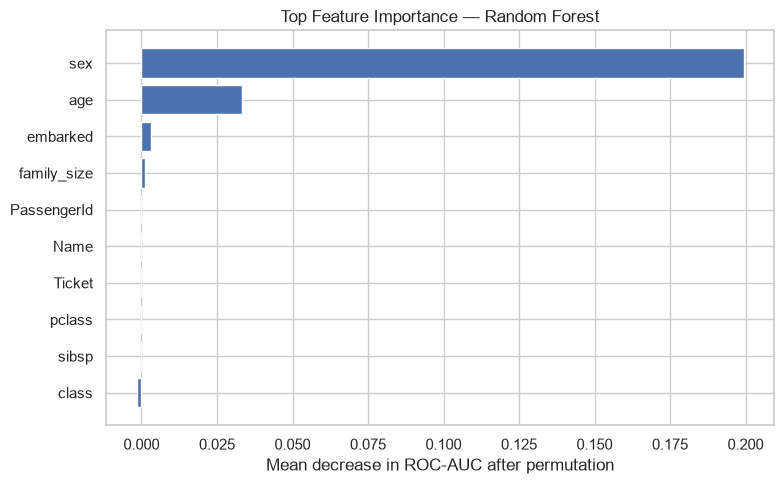

In [17]:
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    scoring="roc_auc",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance Mean": perm.importances_mean,
    "Importance Std": perm.importances_std
}).sort_values("Importance Mean", ascending=False)

display(importance_df.round(4))

top_n = min(10, len(importance_df))
plot_df = importance_df.head(top_n).sort_values("Importance Mean")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(plot_df["Feature"], plot_df["Importance Mean"])
ax.set_xlabel("Mean decrease in ROC-AUC after permutation")
ax.set_title(f"Top Feature Importance — {best_model_name}")
plt.tight_layout()
plt.show()

## 11. Strengths and Limitations

### Strengths
- Uses a complete supervised-learning workflow.
- Uses a stratified train-test split.
- Uses five-fold stratified cross-validation.
- Applies feature engineering based on family/travel structure.
- Uses pipelines to reduce preprocessing leakage.
- Compares an interpretable linear baseline with a nonlinear ensemble.
- Evaluates several complementary classification metrics.
- Includes confusion-matrix, ROC-curve and permutation-importance analysis.

### Limitations
- The dataset is relatively small and represents a single historical event.
- Several variables have missing information.
- `fare_per_person` is an approximation based on recorded family size.
- Historical passenger data may contain sampling and measurement limitations.
- Results may not generalize to a different population or context.
- Predictive associations should not be interpreted as causal relationships.

### Possible Improvements
- Broader hyperparameter optimization.
- Comparison with additional algorithms such as Gradient Boosting or SVM.
- Repeated cross-validation for more stable estimates.
- Probability calibration.
- Additional domain-informed feature engineering.
- Independent external validation if a suitable dataset is available.

## 12. Results and Analytical Discussion

After executing the notebook, the final report should discuss the actual values produced rather than using generic statements.

The discussion should answer:

1. Which model achieved the strongest cross-validation ROC-AUC?
2. Did its held-out test performance remain comparable?
3. Are precision and recall balanced?
4. What types of errors appear in the confusion matrix?
5. Which original or engineered features are most useful?
6. Why might those features be predictive?
7. What does the model tell us about the dataset?
8. What conclusions **cannot** be made because of the dataset's limitations?

### Interpretation rule
Do not write only *"the model achieved good accuracy."* Explain the metric, compare validation with test performance, examine errors, and connect the result to the data.

# 13. Conclusion

This project implements a complete supervised-learning classification workflow for Titanic survival prediction, including data exploration, feature engineering, leakage-aware preprocessing, model comparison, stratified cross-validation, held-out testing, hyperparameter tuning and model interpretation.

The final conclusion should be completed using the **actual execution results**. It should identify the strongest model, summarize its performance across multiple metrics, explain the most useful features, and discuss the practical meaning and limitations of the predictions.

**Key takeaway:** a supervised learning project is not complete when a model produces predictions; the model must also be validated, evaluated from multiple perspectives, interpreted in context, and critically assessed for limitations.